# 1. Supervised Learning — Principles and Pipeline

**Supervised Learning** implies that data come as pairs: for each $\boldsymbol{x} \in \mathbb{R}^d$, we have a $\boldsymbol{y} \in \mathbb{Y}$ (containing the answer to what you aim to predict). The set of all $n$ pairs $\{(\boldsymbol{x}^{(i)}, \boldsymbol{y}^{(i)})\}_{i=1}^n$ is called the **training set**.

Depending on the nature of $\mathbb{Y}$, there are two main tasks in supervised learning:
- **Regression**: $\mathbb{Y}$ is continuous (e.g., predict a temperature, an energy, a velocity field or the value of a stock),
- **Classification**: $\mathbb{Y}$ is discrete (e.g., malignant or benign tumor or distinguishing images of trucks, planes, cars and bicycles).

### Training phase
The goal of learning is to **train** a parameterized **model** $f_\theta : \mathbb{R}^d \to \mathbb{Y}$ approximating the targets $\boldsymbol{y}^{(i)}$ using the training set.

**Cost (or risk) function:** Measures the error committed by the model $f_\theta$ on a dataset $\boldsymbol{X}$. We denote it $R(\boldsymbol{X}, \boldsymbol{\theta})$. *Training* a model actually means finding the $\hat{\boldsymbol{\theta}}$ minimizing the cost $R_\mathrm{train} = R(\boldsymbol{X}, \hat{\boldsymbol{\theta}})$.

### Generalization phase

The overall goal of supervised learning is then to use the trained model $f_{\hat{\boldsymbol{\theta}}}$ on new data $\tilde{\boldsymbol{x}}$ and check its performance using the test error $R_\mathrm{test} = R(\tilde{\boldsymbol{X}}, \hat{\boldsymbol{\theta}})$.

Comparing both train and test errors will help us detect some generalization issues (overfitting and underfitting).

### Outline
The aim of this notebook is to show the **pipeline** of supervised learning:
1. Loading and preparing data,
2. Splitting it into train / validation / test,
3. Training a model (without explaining it),
4. Evaluating it on a validation and test set,
5. Detecting overfitting and underfitting.

The cell below just loads some packages we will need to train our models and visualize the results.

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, GridSearchCV
from sklearn.metrics import mean_squared_error, accuracy_score, ConfusionMatrixDisplay, roc_curve, roc_auc_score

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.dummy import DummyRegressor, DummyClassifier

# Formatting the plots
plt.rcParams['figure.figsize'] = [6,6]
plt.rcParams['font.size'] = 18
plt.rcParams['font.weight'] = 'normal'
plt.style.use('default')
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['mathtext.rm'] = 'serif'
mpl.rcParams['font.size'] = 22
mpl.rcParams['axes.formatter.limits'] = (-6, 6)
mpl.rcParams['axes.formatter.use_mathtext'] = True
mpl.rcParams['font.family'] = 'STIXGeneral'
mpl.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
mpl.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
mpl.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.minor.visible'] = True

# 2. A first example: California Housing

### Preparing and analyzing the data

We use the **California Housing dataset** from 1990's data.  
Each row corresponds to a **district** in California.

- **Number of samples (rows):** 20,640  
- **Number of features (columns):** 8  
- **Features:**
  - `MedInc`: median income in the district  
  - `HouseAge`: median house age  
  - `AveRooms`: average number of rooms per house  
  - `AveBedrms`: average number of bedrooms per house  
  - `Population`: district population  
  - `AveOccup`: average household occupancy  
  - `Latitude` and `Longitude`: geo-coordinates  

- **Target:** Median house value, in 100,000 USD.

**Q1.** What family of supervised learning problem are we dealing with and why?

The code below loads the data and prints it.

In [459]:
cal = datasets.fetch_california_housing(as_frame=True)
cal.frame       # This is a pandas dataframe

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


**Q2.** What is the name of the target in the dataframe? Extract it and build a target vector $\boldsymbol{y}$. Do the same to build a matrix $\boldsymbol{X}$ containing all features. Hint: have a look at the [`drop`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html) function from ```Pandas```.

In [460]:
# YOUR CODE
X = cal.frame.drop(columns=['MedHouseVal'])
y = cal.frame['MedHouseVal']

**Q3.** Analyze the target vector. Do you see any issue? Comment.

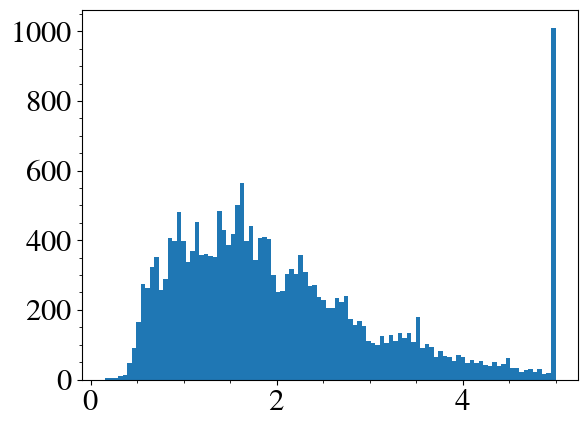

In [461]:
# YOUR CODE
_ = plt.hist(y, bins=100)

**Q4.** Now analyze the feature matrix $\boldsymbol{X}$. In particular, do you see any missing value? Use the [`isna`](https://pandas.pydata.org/docs/reference/api/pandas.isna.html) function.

In [462]:
# YOUR CODE HERE
X.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In supervised learning, we make use of three different sets:
- **Training set:** used to fit the parameters of the model,
- **Validation set:** used to fit the hyperparameters,
- **Test set:** used to compare models. **Never fit anything on this set.**

**Q5.** Prepare the dataset and split it into 70% training, 15% validation and 15% test using the scikit-learn [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function.

In [ ]:
# YOUR CODE HERE
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=32)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=32)

X_train.shape, X_val.shape, X_test.shape

((14448, 8), (3096, 8), (3096, 8))

Since the data may have different magnitudes, it is a good practice to always standardize it by subtracting the mean, and dividing by the standard deviation. This way the column of the datasets have zero mean and unit variance. However, it is important to avoid **data leakage** when doing so: the mean and variance should be computed using the training set only, and then applied on test and validation sets.

In [464]:
# Fit scaler ONLY on the training set
scaler = StandardScaler().fit(X_train)

# Transform all splits
X_train = scaler.transform(X_train)     # Now has zero mean and unit variance
X_val   = scaler.transform(X_val)       # Is standardized with respect to the training set
X_test  = scaler.transform(X_test)      # Is standardized with respect to the training set

df_train = pd.DataFrame(data=X_train)
print(df_train)

              0         1         2         3         4         5         6  \
0     -0.098904  0.033126 -0.277487 -0.141770  0.423618  0.283389 -0.704702   
1      1.486791 -1.001607  0.855761 -0.160482 -0.500266  0.169758 -0.821512   
2     -0.531636  1.863808 -0.037103  0.200298  0.254073 -0.088875  1.000726   
3      0.302882  1.147454  0.102679 -0.113594 -0.885596  0.021838  0.776450   
4      0.286320 -1.240392  8.859767  8.110474 -1.061487 -0.122169  1.225001   
...         ...       ...       ...       ...       ...       ...       ...   
14443 -0.570758  0.988264 -0.268962 -0.081380 -0.679784 -0.185248  0.935312   
14444 -0.168018 -1.399581 -0.432232 -0.066186  1.510701 -0.164185 -0.681340   
14445 -1.107109  0.351505 -0.411762 -0.193486 -0.339788  0.109461  1.631500   
14446 -0.285597  0.829074  0.053338  0.366893  0.023782  0.126717  0.346589   
14447  0.495307  0.431100 -0.082161 -0.107036 -0.634451  0.141104 -0.877581   

              7  
0      0.795510  
1      0.895208

### A first dummy model

**Q6.** What is the simplest model you can think of? Implement it. Hint: you may want to use the [`DummyRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html) class from scikit-learn.

In [ ]:
# YOUR CODE HERE
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
pred_val_baseline = baseline.predict(X_val)

**Q7.** What do you think is an appropriate measure of the error (i.e. cost function) for this kind of problems? Implement it and compute the performance of your baseline on the test set.

In [ ]:
def cost(y_true, y_pred):
    # YOUR CODE HERE
    R = ((y_true - y_pred)**2).mean()
    return R

val_error_baseline = cost(y_val, pred_val_baseline)

**Q8.**  Check out the [`scikit-learn`](https://scikit-learn.org/stable/api/sklearn.metrics.html) list of metrics. Do you see the one you proposed? Compared with your implementation.

In [467]:
# YOUR CODE HERE
val_error_baseline_sklearn = mean_squared_error(y_val, pred_val_baseline)
print(val_error_baseline, val_error_baseline_sklearn)

1.3585633618665376 1.3585633618665376


### Training a better model with scikit-learn

All the models of scikit-learn are working in the same way:
- Define an instance of a model class as ```model_name(hyperparameter1, hyperparameter2, cost_function, ...)```,
- Use the ```.fit()``` attribute of the model to train the parameters by minimizing the cost function,
- Use the ```.predict(X)```attribute of the model to predict the output of the model on a given set $X$.

**Q9.** Have a look at the [scikit-learn list of models](https://scikit-learn.org/stable/supervised_learning.html). Train the [```Ridge```](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge) model using the pipeline above. So far we won't explain how this model work. Pick a value for $\alpha$.

In [468]:
# YOUR CODE HERE
reg_model = Ridge(alpha=10)
reg_model.fit(X_train, y_train)

Ridge(alpha=10)

**Q10.** Compare the model to the baseline on the test set. What do you conclude?

In [469]:
# YOUR CODE HERE
pred_val = reg_model.predict(X_val)    
print("Model MSE (test):", mean_squared_error(y_val, pred_val))
print("Baseline MSE (test):", val_error_baseline)

Model MSE (test): 0.5313365677908141
Baseline MSE (test): 1.3585633618665376


**Q11.** Vary $\alpha$, the hyperparameter of the ridge model in the interval $[0, 50]$, and compute the validation error. What do you see as $\alpha$ grows? What optimal value would you choose for alpha?

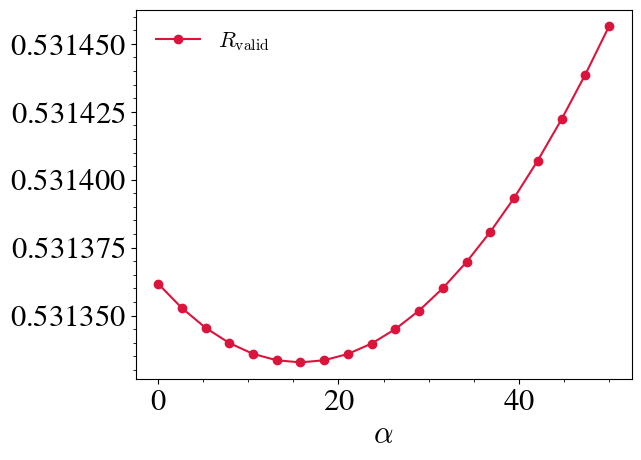

In [470]:
alphas = np.linspace(0, 50, 20)
val_errors = []
train_errors = []
for alpha in alphas:
    # YOUR CODE HERE
    reg_model = Ridge(alpha=alpha)          # Create a Ridge regression model with the current alpha
    reg_model.fit(X_train, y_train)         # Fit the model on the training data
    
    # Compute the validation error
    pred_val = reg_model.predict(X_val)     # Predict on the validation set
    val_error = mean_squared_error(y_val, pred_val) # Compute the validation error (MSE)
    val_errors.append(val_error)            # Store the validation error

# Plotting
fig, ax = plt.subplots()
ax.plot(alphas, val_errors, color='crimson', marker='o', label=r'$R_\mathrm{valid}$')
ax.legend(frameon=False, fontsize=16)
ax.set_xlabel(r'$\alpha$')
plt.show()

This way of fitting the hyperparameter $\alpha$ is called grid search. A more robust version of it is [```K-cross validation```](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) which repeatedly evaluate the validation error over a held-out fold of the data and average it.

The idea is to:
- Split the training data into $K$ folds,
- For each fold, train the model on $K-1$ folds and evaluate the validation error on the $K$th,
- Compute the average error over the $K$ iterations.

Below is a scikit-learn implementation of cross-validation with $K=5$.


In [498]:
pipe = Pipeline([('scale', StandardScaler()),        # Standardized the data
                 ('ridge', Ridge(random_state=42))]  # Apply Ridge model
                )

alphas = np.logspace(-3, 3, 25)
param_grid = {'ridge__alpha': alphas}

gscv = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    return_train_score=True
)
gscv.fit(X, y)

best_alpha = gscv.best_params_['ridge__alpha']
best_mse = -gscv.best_score_
print(f"Best alpha = {best_alpha:.5g}  |  CV MSE = {best_mse:.4f}")

best_model = gscv.best_estimator_       # Already refit on full training folds

Best alpha = 17.783  |  CV MSE = 0.5583


### Generalization problems

**Q12.** In the code below, we vary $\alpha$ and compute the train and validation errors at the end of training. What regimes do you see, and how you interpret it?

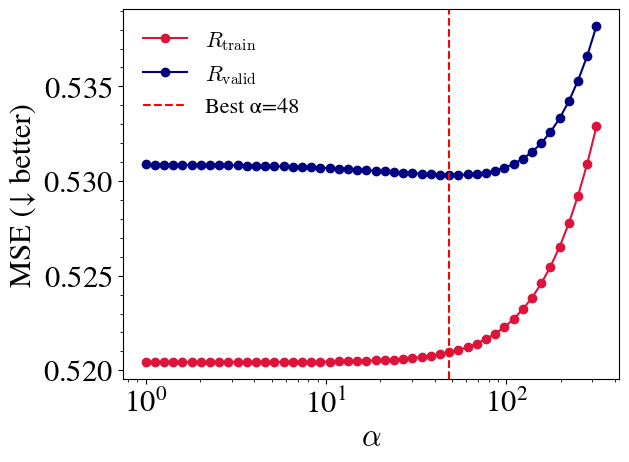

Best alpha: 48.27 | Val MSE: 0.5303 | Train MSE: 0.5209


In [497]:
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.5, random_state=42)

alphas = np.logspace(0, 2.5, 50)
mse_tr, mse_val = [], []

for a in alphas:
    model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=a, random_state=42)
    )
    model.fit(X_tr, y_tr)
    ytr = model.predict(X_tr)
    yva = model.predict(X_val)
    mse_tr.append(mean_squared_error(y_tr, ytr))
    mse_val.append(mean_squared_error(y_val, yva))

mse_tr = np.array(mse_tr); mse_val = np.array(mse_val)
best_idx = np.argmin(mse_val)

# Plotting
plt.figure()
plt.semilogx(alphas, mse_tr, 'o-', label=r'$R_\mathrm{train}$', color='crimson')
plt.semilogx(alphas, mse_val, 'o-', label=r'$R_\mathrm{valid}$', color='navy')
plt.axvline(alphas[best_idx], color='r', ls='--', label=f'Best α={alphas[best_idx]:.2g}')
plt.xlabel(r'$\alpha$'); plt.ylabel('MSE (↓ better)')
plt.legend(frameon=False, fontsize=16)
plt.show()

print(f"Best alpha: {alphas[best_idx]:.4g} | Val MSE: {mse_val[best_idx]:.4f} | Train MSE: {mse_tr[best_idx]:.4f}")

# 3. A second example: Breast Cancer (Wisconsin dataset)

### Preparing and analyzing the data


This dataset describes characteristics of breast cell nuclei (from a digitized image of a biopsy).

- **Number of samples (rows):** 569  
- **Number of features (columns):** 30 real-valued features  
- **Features examples:**
  - `mean radius`: average size of cell nuclei,
  - `mean texture`: variation in gray-scale values,  
  - `mean perimeter`, `mean area`, `mean smoothness`, …  
  (in total: 10 properties × mean, standard error, worst = 30 features)

- **Target (`y`):**
  - `0` = malignant tumor  
  - `1` = benign tumor

**Q13.** What family of supervised learning problem are we dealing with and why?

In [444]:
bc = datasets.load_breast_cancer(as_frame=True)
X = bc.frame.drop(columns=['target'])
y = bc.frame['target']

**Q14.** Use our previous code to prepare the dataset in a train/validation/test split.

In [445]:
# YOUR CODE HERE
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_train.shape, X_val.shape, X_test.shape

((398, 30), (85, 30), (86, 30))

**Q15.** Have a look at the training target vector. Is the dataset balanced?

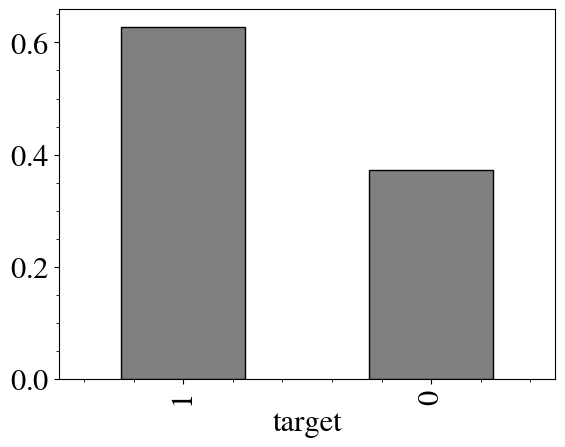

In [446]:
# Your code
y_train.value_counts(normalize=True).plot.bar(fc='grey', ec='k')
plt.show()

### Training and comparing models

The dummy model we'll be using is to systematically predict the most frequent class.

**Q16.** What natural error measure can you think of for classification? Do you have an intuition of when it does fail?

In [447]:
clf_base = DummyClassifier(strategy='most_frequent')        # Most frequent model
clf_base.fit(X_train, y_train)                              # Fitting the training data
acc_base_val = clf_base.score(X_val, y_val)              # Computing the score
print("Baseline accuracy (val):", acc_base_val)           # Printing

Baseline accuracy (val): 0.6235294117647059


**Q17.** Again, scikit-learn implements a lot of models for classification. One of the simplest one is [```Logistic regression```](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression). Implement it, train it, and evaluate it on the test set. Comment.

In [448]:
# YOUR CODE HERE
clf = LogisticRegression()
clf.fit(X_train, y_train)

pred_val = clf.predict(X_val)
acc = accuracy_score(y_val, pred_val)
print("Validation accuracy:", acc)

Validation accuracy: 0.9764705882352941


/opt/anaconda3/envs/PR/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Q18.** Remind what the ROC curve is. Is it a good idea of using it here? Compute it for our two models using the [```roc_cruve```](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html) function from scikit-learn. Comment.

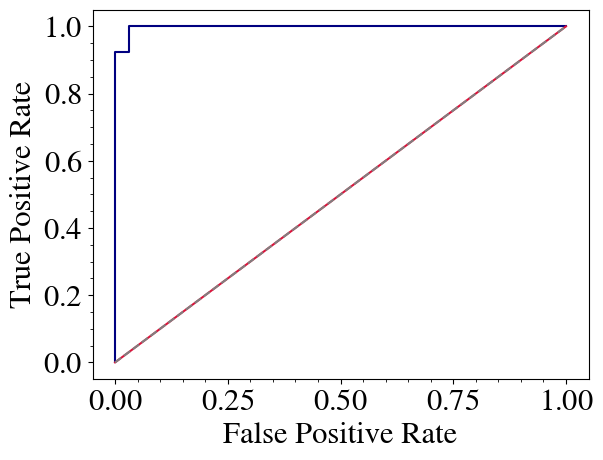

In [449]:
# YOUR CODE HERE
proba_val = clf.predict_proba(X_val)[:, 1]
fpr, tpr, thr = roc_curve(y_val, proba_val)

proba_val_base = clf_base.predict_proba(X_val)[:, 1]
fpr_base, tpr_base, thr_base = roc_curve(y_val, proba_val_base)

# Plotting function
plt.plot(fpr, tpr, color='navy')
plt.plot(fpr_base, tpr_base, color='crimson')
plt.plot([0,1],[0,1],'--', color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

### 